<a href="https://colab.research.google.com/github/Adeela-saleem/MachineLearning_Algorithms/blob/main/LogisticRegressionPerceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [2]:
import matplotlib.pyplot as plt


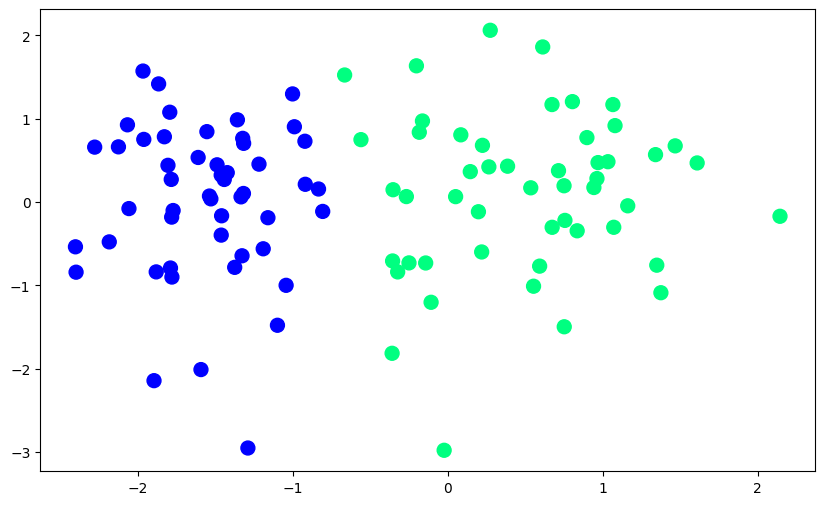

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [4]:
def perceptron(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]


In [5]:
def step(z):
    return 1 if z>0 else 0


In [6]:
intercept_,coef_ = perceptron(X,y)

In [7]:
print(coef_)
print(intercept_)


[1.36938955 0.21208618]
0.9


Slope: $m = -\frac{w_1}{w_2}$Y-intercept: $b = -\frac{w_0}{w_2}$

In [8]:

m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [9]:

x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

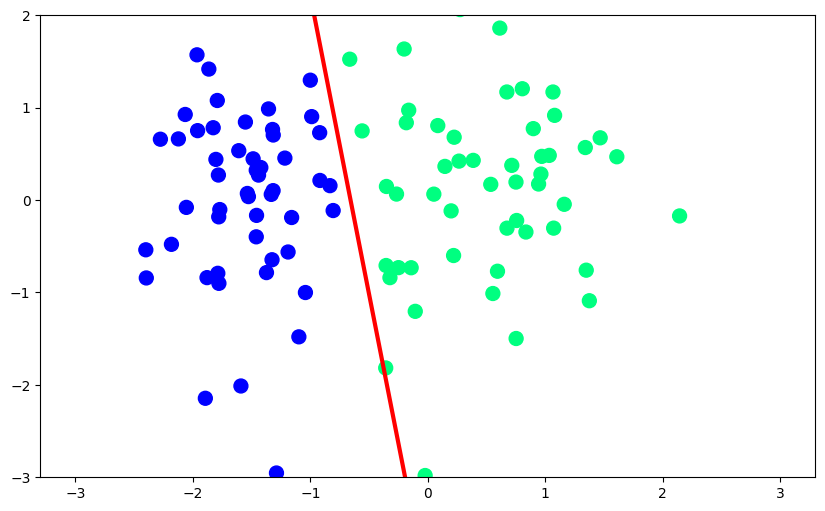

In [10]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [11]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [12]:
m = -(lor.coef_[0][0] / lor.coef_[0][1])
b = -(lor.intercept_[0] / lor.coef_[0][1])  # <-- Yahan [0] add karein

In [13]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m * x_input1 + b   # <-- Yahan x_input1 karein

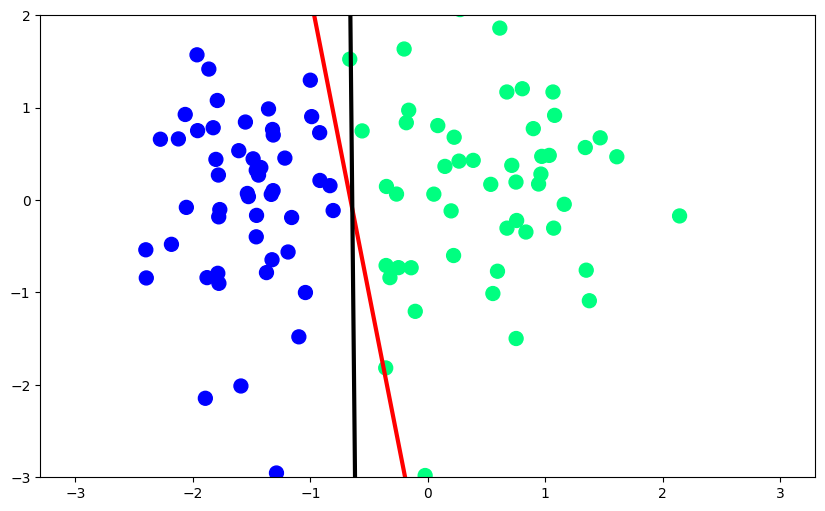

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(x_input, y_input, color='red', linewidth=3)      # Perceptron line
plt.plot(x_input1, y_input1, color='black', linewidth=3)  # Logistic Regression line
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)
plt.show()



## 📌 Summary: Perceptron vs. Logistic Regression

Is notebook mein humne **Perceptron** aur **Logistic Regression** ke zariye binary classification perform ki aur dono ke seekhe gaye decision boundaries ko compare kiya:

### 1. Data Generation

* `make_classification` function ka istemal karte hue 2-features waala synthetic binary classification dataset create kiya.

### 2. Custom Perceptron Algorithm

* **Step Function:** Activation ke liye simple step function ($\ge 0 \rightarrow 1$, else $0$) write kiya.
* **Weights Update Rule:** Perceptron learning rule ke mutabiq weights update kiye:

$$\text{weights} = \text{weights} + \text{learning\_rate} \times (y - \hat{y}) \times X$$


* **Decision Boundary Calculation:**
* Slope: $m = -\frac{w_1}{w_2}$
* Y-intercept: $b = -\frac{w_0}{w_2}$



### 3. Logistic Regression (Scikit-Learn)

* Scikit-learn ki `LogisticRegression` class se model train kiya.
* `lor.coef_` aur `lor.intercept_` se parameters extract karke decision boundary ki line calculate ki:
* Slope: $m = -\frac{\text{coef}[0]}{\text{coef}[1]}$
* Y-intercept: $b = -\frac{\text{intercept}}{\text{coef}[1]}$



### 4. Visual Comparison

* Perceptron (Red Line) aur Logistic Regression (Black Line) dono ki decision boundaries ko ek saath scatter plot par plot karke dekha ke dono models points ko kis tarah separate karte hain.